<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/260719_Paderborn_E2E_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 김반장 LITE — Paderborn E2E 학습 (RAM 최적화)

| 항목 | 값 |
|------|-----|
| 입력 | Raw 512샘플 vibration_1 (64kHz) |
| 정상 | K001~K006 (6종) |
| 결함 | KA01~KA30, KI01~KI21, KB23/24/27 |
| RAM 전략 | 베어링별 최대 2,000 윈도우 서브샘플링 → 전체 ~64K 윈도우 |
| 그룹 분할 | 베어링 코드 단위 완전 분리 (누수 차단) |

In [1]:
# ============================================================
# 셀 0. Drive 마운트 & 서브샘플링 로드 (RAM 최적화)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, os

NPZ_PATH = '/content/drive/MyDrive/Colab Notebooks/paderborn_raw_windows.npz'

# ★ 베어링별 최대 윈도우 수 (RAM 절약 핵심)
MAX_PER_BEARING = 2000
SEED = 42
rng  = np.random.default_rng(SEED)

print('NPZ 로드 중 (mmap)...')
data = np.load(NPZ_PATH, mmap_mode='r', allow_pickle=True)
bearing_codes_all = data['bearing_codes']          # 문자열 배열, 가볍게 먼저 로드
y_binary_all      = data['y_binary']
y_multi_all       = data['y_multi']

# 베어링별 인덱스 서브샘플링
selected_idx = []
for code in sorted(np.unique(bearing_codes_all)):
    idx = np.where(bearing_codes_all == code)[0]
    n   = min(MAX_PER_BEARING, len(idx))
    chosen = rng.choice(idx, n, replace=False)
    selected_idx.append(chosen)
    print(f'  {code}: {len(idx):,} -> {n}')

sel = np.sort(np.concatenate(selected_idx))
print(f'\n선택 윈도우: {len(sel):,}개  (전체 {len(bearing_codes_all):,}개 중)')

# 선택된 인덱스만 실제 메모리로 로드
print('선택 샘플 메모리 로드...')
X             = np.array(data['X'][sel], dtype=np.float32)
y_binary      = np.array(y_binary_all[sel], dtype=np.int32)
y_multi       = np.array(y_multi_all[sel],  dtype=np.int32)
bearing_codes = bearing_codes_all[sel].copy()
del data  # mmap 해제

print(f'X shape : {X.shape}  ({X.nbytes/1024**2:.0f} MB)')
print(f'범위    : [{X.min():.4f}, {X.max():.4f}]')
print('\n이진 라벨 분포:')
for c, name in [(0,'Normal'),(1,'Fault')]:
    print(f'  {name}: {np.sum(y_binary==c):,}')

Mounted at /content/drive
NPZ 로드 중 (mmap)...
  K001: 40,048 -> 2000
  K002: 40,121 -> 2000
  K003: 40,100 -> 2000
  K004: 40,042 -> 2000
  K005: 40,081 -> 2000
  K006: 40,071 -> 2000
  KA01: 40,073 -> 2000
  KA03: 40,387 -> 2000
  KA04: 40,028 -> 2000
  KA05: 40,117 -> 2000
  KA06: 40,039 -> 2000
  KA07: 40,205 -> 2000
  KA08: 39,536 -> 2000
  KA09: 40,087 -> 2000
  KA15: 40,042 -> 2000
  KA16: 40,044 -> 2000
  KA22: 40,153 -> 2000
  KA30: 40,045 -> 2000
  KB23: 40,103 -> 2000
  KB24: 40,077 -> 2000
  KB27: 40,178 -> 2000
  KI01: 40,034 -> 2000
  KI03: 40,116 -> 2000
  KI04: 40,057 -> 2000
  KI05: 40,136 -> 2000
  KI07: 40,124 -> 2000
  KI08: 40,136 -> 2000
  KI14: 40,100 -> 2000
  KI16: 40,349 -> 2000
  KI17: 40,202 -> 2000
  KI18: 40,060 -> 2000
  KI21: 40,057 -> 2000

선택 윈도우: 64,000개  (전체 1,282,948개 중)
선택 샘플 메모리 로드...
X shape : (64000, 512)  (125 MB)
범위    : [-8.6273, 9.6313]

이진 라벨 분포:
  Normal: 12,000
  Fault: 52,000


In [2]:
# ============================================================
# 셀 1. 패키지
# ============================================================
!pip install -q scikit-learn matplotlib seaborn tensorflow

In [3]:
# ============================================================
# 셀 2. 데이터 분할 — 베어링 코드 단위 완전 분리
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight

PHASE = 'A'
y = y_binary if PHASE == 'A' else y_multi
CLASS_NAMES = ['Normal', 'Fault'] if PHASE == 'A' else ['Normal','ArtFault_KA','ArtFault_KI','RealFault_KB']

normal_codes = sorted([c for c in np.unique(bearing_codes) if c.startswith('K0')])
fault_codes  = sorted([c for c in np.unique(bearing_codes) if not c.startswith('K0')])
print(f'정상 베어링({len(normal_codes)}종): {normal_codes}')
print(f'결함 베어링({len(fault_codes)}종): {fault_codes}')

# 정상 6종: Train 4 / Val 1(K005) / Test 1(K006)
# 결함 26종: ~70% Train / ~15% Val / ~15% Test
np.random.seed(42)
fault_arr = np.array(fault_codes)
np.random.shuffle(fault_arr)
n_te  = max(2, int(len(fault_arr) * 0.15))
n_val = max(2, int(len(fault_arr) * 0.15))

test_codes  = set(fault_arr[:n_te].tolist()            + ['K006'])
val_codes   = set(fault_arr[n_te:n_te+n_val].tolist()  + ['K005'])
train_codes = set(fault_arr[n_te+n_val:].tolist()      + [c for c in normal_codes if c not in ['K005','K006']])

assert len(train_codes & test_codes) == 0, 'Train-Test 누수!'
assert len(train_codes & val_codes)  == 0, 'Train-Val 누수!'
assert len(val_codes   & test_codes) == 0, 'Val-Test 누수!'
print('누수 검증 통과')

def make_mask(codes_set):
    return np.array([c in codes_set for c in bearing_codes])

tr_mask  = make_mask(train_codes)
val_mask = make_mask(val_codes)
te_mask  = make_mask(test_codes)

# INT8 범위 스케일링 (-1 ~ +1)
SCALE_MIN = float(X.min())
SCALE_MAX = float(X.max())
X_norm = ((2.0 * (X - SCALE_MIN) / (SCALE_MAX - SCALE_MIN)) - 1.0).astype(np.float32)
X_norm = X_norm[..., np.newaxis]  # (N, 512, 1)
del X  # 원본 해제

X_tr,  y_tr  = X_norm[tr_mask].copy(),  y[tr_mask]
X_val, y_val = X_norm[val_mask].copy(), y[val_mask]
X_te,  y_te  = X_norm[te_mask].copy(),  y[te_mask]
del X_norm

print(f'Train : {X_tr.shape}  {dict(zip(*np.unique(y_tr,  return_counts=True)))}')
print(f'Val   : {X_val.shape}  {dict(zip(*np.unique(y_val, return_counts=True)))}')
print(f'Test  : {X_te.shape}  {dict(zip(*np.unique(y_te,  return_counts=True)))}')

cw_arr       = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = dict(zip(np.unique(y_tr), cw_arr))
print(f'class_weight: {class_weight}')

print(f'\n[STM32 펌웨어 상수]')
print(f'  #define AI_SCALE_MIN  {SCALE_MIN:.6f}f')
print(f'  #define AI_SCALE_MAX  {SCALE_MAX:.6f}f')

정상 베어링(6종): [np.str_('K001'), np.str_('K002'), np.str_('K003'), np.str_('K004'), np.str_('K005'), np.str_('K006')]
결함 베어링(26종): [np.str_('KA01'), np.str_('KA03'), np.str_('KA04'), np.str_('KA05'), np.str_('KA06'), np.str_('KA07'), np.str_('KA08'), np.str_('KA09'), np.str_('KA15'), np.str_('KA16'), np.str_('KA22'), np.str_('KA30'), np.str_('KB23'), np.str_('KB24'), np.str_('KB27'), np.str_('KI01'), np.str_('KI03'), np.str_('KI04'), np.str_('KI05'), np.str_('KI07'), np.str_('KI08'), np.str_('KI14'), np.str_('KI16'), np.str_('KI17'), np.str_('KI18'), np.str_('KI21')]
누수 검증 통과
Train : (48000, 512, 1)  {np.int32(0): np.int64(8000), np.int32(1): np.int64(40000)}
Val   : (8000, 512, 1)  {np.int32(0): np.int64(2000), np.int32(1): np.int64(6000)}
Test  : (8000, 512, 1)  {np.int32(0): np.int64(2000), np.int32(1): np.int64(6000)}
class_weight: {np.int32(0): np.float64(3.0), np.int32(1): np.float64(0.6)}

[STM32 펌웨어 상수]
  #define AI_SCALE_MIN  -8.627319f
  #define AI_SCALE_MAX  9.631348f


In [4]:
# ============================================================
# 셀 3. 1D-CNN 모델
# ============================================================
N_CLASSES = 1 if PHASE == 'A' else len(np.unique(y))

def build_e2e_cnn(window=512, n_classes=1):
    inp = layers.Input(shape=(window, 1), name='vibration_input')
    x = layers.Conv1D(16, 7, strides=2, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    if n_classes == 1:
        out  = layers.Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        out  = layers.Dense(n_classes, activation='softmax', name='output')(x)
        loss = 'sparse_categorical_crossentropy'
    model = models.Model(inp, out, name='AI_KimBanjang_Paderborn')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss, metrics=['accuracy'])
    return model

model = build_e2e_cnn(512, N_CLASSES)
model.summary()

Model: "AI_KimBanjang_Paderborn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vibration_input (InputLayer)    │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,489 (44.88 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 224 (896.00 B)

In [5]:
# ============================================================
# 셀 4. 학습
# ============================================================
from tensorflow.keras import callbacks

cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint('best_paderborn.keras',
                               monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=256,
    class_weight=class_weight,
    callbacks=cb_list, verbose=1
)
print('학습 완료')

Epoch 1/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.7465 - loss: 0.3763 - val_accuracy: 0.7500 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 2/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8123 - loss: 0.2988 - val_accuracy: 0.4174 - val_loss: 1.0889 - learning_rate: 0.0010
Epoch 3/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8354 - loss: 0.2744 - val_accuracy: 0.9028 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 4/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8501 - loss: 0.2600 - val_accuracy: 0.8586 - val_loss: 0.2378 - learning_rate: 0.0010
Epoch 5/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8636 - loss: 0.2434 - val_accuracy: 0.8136 - val_loss: 0.3100 - learning_rate: 0.0010
Epoch 6/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8681 - loss: 0.2368 - val_accuracy: 0.7831 - val_loss: 0.8462 - learning_rate: 0.0010
Epoch 7/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8765 - loss: 0.2255

       Paderborn KPI 평가 결과 (thr=0.5)
  Accuracy  :  80.74%   (목표 >= 98%)
  Macro F1  :  78.72%   (목표 >= 97%)
  FNR (미탐)  :  25.65%   (목표 < 2%)
  FAR (오경보):   0.10%   (목표 < 1%)
  판정: KPI 미달
              precision    recall  f1-score   support

      Normal       0.56      1.00      0.72      2000
       Fault       1.00      0.74      0.85      6000

    accuracy                           0.81      8000
   macro avg       0.78      0.87      0.79      8000
weighted avg       0.89      0.81      0.82      8000



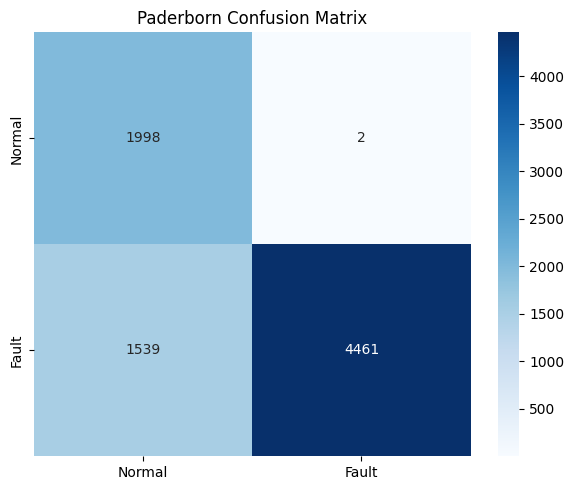

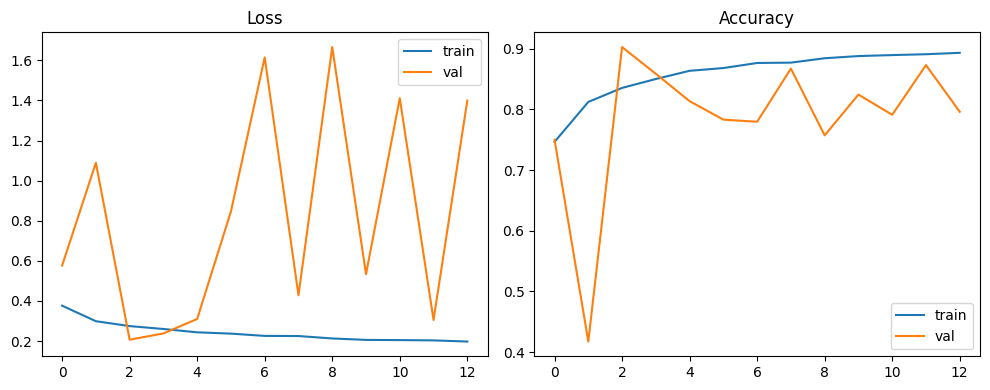

In [6]:
# ============================================================
# 셀 5. 평가 — KPI
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report

prob = model.predict(X_te, batch_size=256, verbose=0)
pred = (prob.ravel() >= 0.5).astype(int) if PHASE == 'A' else np.argmax(prob, axis=1)

acc = accuracy_score(y_te, pred)
mf1 = f1_score(y_te, pred, average='macro')
cm  = confusion_matrix(y_te, pred)

print('=' * 55)
print('       Paderborn KPI 평가 결과 (thr=0.5)')
print('=' * 55)
print(f'  Accuracy  : {acc*100:6.2f}%   (목표 >= 98%)')
print(f'  Macro F1  : {mf1*100:6.2f}%   (목표 >= 97%)')

if PHASE == 'A':
    tn, fp, fn, tp = cm.ravel()
    fnr = fn/(fn+tp)*100 if (fn+tp) else 0
    far = fp/(fp+tn)*100 if (fp+tn) else 0
    print(f'  FNR (미탐)  : {fnr:6.2f}%   (목표 < 2%)')
    print(f'  FAR (오경보): {far:6.2f}%   (목표 < 1%)')
    ok = acc >= 0.98 and fnr < 2.0 and far < 1.0
    print(f'  판정: {"KPI 달성" if ok else "KPI 미달"}')
print('=' * 55)
print(classification_report(y_te, pred, target_names=CLASS_NAMES))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Paderborn Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_paderborn.png', dpi=150)
plt.show()

# 학습 곡선
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig('training_curve_paderborn.png', dpi=150)
plt.show()

In [7]:
# ============================================================
# 셀 6. 임계값 튜닝
# ============================================================
if PHASE == 'A':
    prob_te = model.predict(X_te, batch_size=256, verbose=0).ravel()
    print(f"{'thr':>5}  {'FNR%':>7}  {'FAR%':>7}  {'Acc%':>7}  {'MacroF1':>9}  {'KPI'}")
    print('-' * 52)
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.arange(0.10, 0.96, 0.05):
        p = (prob_te >= thr).astype(int)
        c = confusion_matrix(y_te, p)
        if c.size < 4: continue
        tn2, fp2, fn2, tp2 = c.ravel()
        fnr2 = fn2/(fn2+tp2)*100 if (fn2+tp2) else 0
        far2 = fp2/(fp2+tn2)*100 if (fp2+tn2) else 0
        acc2 = (tn2+tp2)/c.sum()*100
        mf2  = f1_score(y_te, p, average='macro')*100
        ok   = '<-- PASS' if (fnr2 < 2 and far2 < 1 and acc2 >= 98) else ''
        print(f'{thr:>5.2f}  {fnr2:>7.2f}  {far2:>7.2f}  {acc2:>7.2f}  {mf2:>9.2f}  {ok}')
        if fnr2 < 2 and far2 < 1 and mf2 > best_f1:
            best_f1, best_thr = mf2, round(float(thr), 2)
    print(f'\n권장 임계값: {best_thr}  (MacroF1={best_f1:.2f}%)')
else:
    best_thr = 0.5

  thr     FNR%     FAR%     Acc%    MacroF1  KPI
----------------------------------------------------
 0.10     9.18    33.30    84.79      79.31  
 0.15    13.65    15.95    85.78      82.41  
 0.20    16.45     8.20    85.61      82.92  
 0.25    18.60     4.55    84.91      82.49  
 0.30    20.18     2.00    84.36      82.13  
 0.35    21.80     0.95    83.41      81.26  
 0.40    23.22     0.50    82.46      80.36  
 0.45    24.50     0.20    81.58      79.52  
 0.50    25.65     0.10    80.74      78.72  
 0.55    26.80     0.10    79.88      77.90  
 0.60    27.93     0.00    79.05      77.12  
 0.65    28.92     0.00    78.31      76.42  
 0.70    29.65     0.00    77.76      75.91  
 0.75    30.58     0.00    77.06      75.25  
 0.80    31.27     0.00    76.55      74.77  
 0.85    32.05     0.00    75.96      74.23  
 0.90    32.70     0.00    75.48      73.77  
 0.95    33.17     0.00    75.12      73.45  

권장 임계값: 0.5  (MacroF1=0.00%)


In [8]:
# ============================================================
# 셀 7. TFLite INT8 변환
# ============================================================
import tensorflow as tf

def representative_dataset():
    idx = np.random.choice(len(X_tr), min(200, len(X_tr)), replace=False)
    for i in idx:
        yield [X_tr[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

print('TFLite INT8 변환 중...')
tflite_model = converter.convert()

TFLITE_PATH = 'paderborn_int8.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp_det = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
inp_scale, inp_zp = inp_det['quantization']
out_scale, out_zp = out_det['quantization']

print(f'저장: {TFLITE_PATH}  ({len(tflite_model)/1024:.1f} KB)')
print(f'Input  scale={inp_scale:.8f}, zero_point={inp_zp}')
print(f'Output scale={out_scale:.8f}, zero_point={out_zp}')

TFLite INT8 변환 중...
Saved artifact at '/tmp/tmpizkk__ss'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 1), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137031555748432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199416848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199418192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199415696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199416272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199419152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199418576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199417808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199420112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137031199420304: TensorSpec(shape=(), dtype=tf.resource, name=None

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


저장: paderborn_int8.tflite  (27.4 KB)
Input  scale=0.00460783, zero_point=8
Output scale=0.00390625, zero_point=-128


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [9]:
# ============================================================
# 셀 8. 양자화 검증 + 헤더 + Drive 저장
# ============================================================
import shutil
from sklearn.metrics import accuracy_score

n_eval = min(500, len(X_te))
tflite_preds = []
for i in range(n_eval):
    x_q = np.clip(np.round(X_te[i:i+1] / inp_scale + inp_zp), -128, 127).astype(np.int8)
    interp.set_tensor(inp_det['index'], x_q)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    tflite_preds.append(int(out.ravel()[0] > 0) if PHASE == 'A' else int(out.argmax()))

keras_raw   = model.predict(X_te[:n_eval], batch_size=256, verbose=0)
keras_preds = (keras_raw.ravel() >= 0.5).astype(int).tolist() if PHASE == 'A' else keras_raw.argmax(axis=1).tolist()

match_rate  = np.mean(np.array(tflite_preds) == np.array(keras_preds)) * 100
tflite_acc  = accuracy_score(y_te[:n_eval], tflite_preds) * 100

print(f'Argmax 일치율 : {match_rate:.2f}%  (목표 100%)')
print(f'TFLite 정확도 : {tflite_acc:.2f}%')

# 펌웨어 헤더 생성
FAULT_THR = best_thr
header = f"""/**
 * AI 김반장 LITE - Paderborn 모델 상수 (자동 생성)
 */
#ifndef AI_KIM_BANJANG_PADERBORN_H
#define AI_KIM_BANJANG_PADERBORN_H
#define AI_WINDOW_SIZE        {512}U
#define AI_SCALE_MIN          {SCALE_MIN:.6f}f
#define AI_SCALE_MAX          {SCALE_MAX:.6f}f
#define AI_INPUT_SCALE        {inp_scale:.8f}f
#define AI_INPUT_ZERO_POINT   ({int(inp_zp)})
#define AI_OUTPUT_SCALE       {out_scale:.8f}f
#define AI_OUTPUT_ZERO_POINT  ({int(out_zp)})
#define AI_FAULT_THRESHOLD    {FAULT_THR:.2f}f
#endif
"""
with open('paderborn_constants.h', 'w') as f:
    f.write(header)

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/AI_KimBanjang_Paderborn'
os.makedirs(SAVE_DIR, exist_ok=True)
for fname in ['best_paderborn.keras', 'paderborn_int8.tflite',
               'paderborn_constants.h', 'confusion_paderborn.png',
               'training_curve_paderborn.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))
        print(f'  저장: {fname}')

print('\n완료! 다음 단계: ST Edge AI 변환')

Argmax 일치율 : 90.00%  (목표 100%)
TFLite 정확도 : 90.00%
  저장: best_paderborn.keras
  저장: paderborn_int8.tflite
  저장: paderborn_constants.h
  저장: confusion_paderborn.png
  저장: training_curve_paderborn.png

완료! 다음 단계: ST Edge AI 변환
